# Moseley et al. 2015
Complex example with temporally variable $^{230}$Th initial incorporation.

Moseley et al. (2015) present U-Th analyses from a Holocene age speleothem. Moseley et al. (2015) note four distinct growth regions and perform isochron analysis to establish ($^{230}$Th/$^{232}$Th)$_{A0}$ for each. The authors report a range of values from ~3 to ~25 with each layer have a distinct value - ~3, 11, 18, and 25. This present an interesting case for the applicability of Th0Th to such a complex case with know heterogeniety. However, with the model design to produce some non-parameteric distribution, the ability to handle complex multi-modal cases is in-built. We do not separate this data by distinct growth interval but consider it a complete system to test if IBIS can detect potentially mulitple phases with varying ($^{230}$Th/$^{232}$Th)$_{A0}$.


In [41]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

In [42]:
import ibis

In [43]:
from ibis import IBIS_Main

In [46]:
# Meta Dictionary with all information - users can tune to their liking here

_META = dict(
        # depth handling
        depth_increases_down=True,
        depth_tol=0.0,  # 0 => no rounding

        # boutique sampler
        fraction_det=0.2,
        r02_clip_lo=0.001,
        r02_clip_hi=1000.0,

        # r02 max bound from data (IMPORTANT)
        r02_max_k_sigma=3.0,  # use (r08+kσ)/(r28-kσ)

        # r02 relative uncertainty proposal
        r02_err_mode="halfnorm",   # "fixed"|"uniform"|"halfnorm"
        r02_rel_err=0.25,
        r02_rel_min=0.005,
        r02_rel_max=1.0,

        # validity gates
        age_sigma_gate=2.0,
        age_eps=1e-12,

        # sigma cheating prevention (EB): default False
        use_r02_in_sigma=True,

        # batch sampler controls
        batch_size = 1000,
        max_batches=1000,
        keep_frac=0.08,
        keep_factor=8,

        # layer windows
        neighbors=1,

        # pair weighting
        pair_weight_mode="exp",   # "none"|"exp"|"power"
        pair_tau_layers=2.0,
        pair_alpha=1.0,
        min_pair_weight=1e-6,

        # prior mixture
        global_mass=0.5,
        n_samples_global=4000,
        n_samples_layer=1000,

        # KDE fit controls
        kde_beta=0.5,
        bw_grid=None,
        cv=5,
        bw_subsample=3000,
        grid_n=1200,
        hi_pct=99.9,
        floor_pdf=1e-12,
    Verbose = True
    )

In [54]:

mm = IBIS_Main.IBIS('/Users/johncarter/Desktop/Moseley_2015_All_IBIS_Input.xlsx',
    sample_name='Moseley_2015_ibis',          
    MCMC_samples=1000000,
    MCMC_burn_in=500000,
    MCMC_Strat_samples=300000,
    n_chains=3,
    Start_from_pickles=False, 
    show_bird=False, 
    method='thoth',
    strat_resolution=100, 
                    diction_meta= _META,
)


Data loaded successfully from /Users/johncarter/Desktop/Moseley_2015_All_IBIS_Input.xlsx (Excel)
All results will save to: /Users/johncarter/Desktop/Moseley_2015_ibis_folder


In [55]:
mm.Set_Up_MCMC()

Ages, uncertainties, and maximum age saved to /Users/johncarter/Desktop/Moseley_2015_ibis_folder/Moseley_2015_ibis_bounds.pkl
Bounds and uncertainties computed and saved.
♻️  Loaded existing Thorium prior from
/Users/johncarter/Desktop/Moseley_2015_ibis_folder/Moseley_2015_ibis_prior.pkl


In [56]:
moseley_vals = np.array([3.1, 18.5, 11.9, 24.4])
moseley_errs = np.array([6.2, 5.4, 2.2, 5.6])

(0.0, 0.17651117003680408)

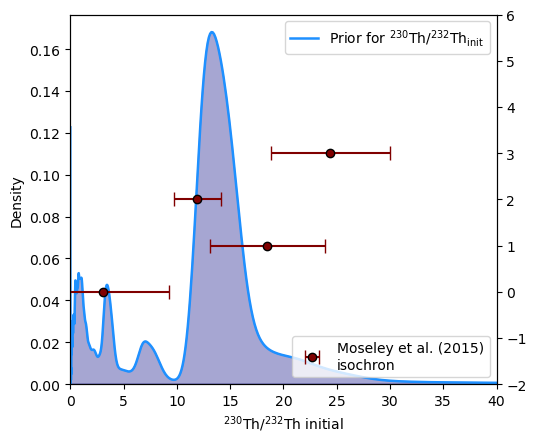

In [57]:
# Plot of the IBIS derived prior using composite 
# global and neighbour estimates
# for comparison "True" are overlain
fig, ax = mm.Plot_Priors()
ax2 =ax.twinx() # Twin x-axis
ax2.errorbar(x = moseley_vals, 
             xerr = moseley_errs, 
             y = np.arange(moseley_errs.size), 
             fmt = 'o', 
             capsize = 5, color = 'maroon', 
            label = 'Moseley et al. (2015)\nisochron', 
            markeredgecolor= 'k')
ax.legend(loc = 'upper right')
ax2.set_ylim(-2, 6)
ax2.legend(loc = 'lower right')
ax.set_xlim(0, 40)
ax2.set_xlim(0, 40)
ax.set_ylim(bottom = 0.0)

In [58]:
mm.Run_MCMC()

Generating new starting θ’s


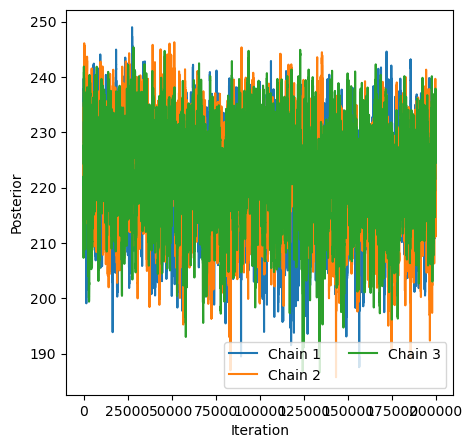

In [59]:
mm.Posterior_plot()

In [82]:
# Save summary to folder
mm.SaveSummary(); 

IBIS summary saved to: /Users/johncarter/Desktop/Moseley_2015_ibis_folder/Moseley_2015_ibis_ibis_summary.csv
Summary saved to Moseley_2015_ibis_ibis_summary.csv


In [83]:
df_summary = pd.read_csv("/Users/johncarter/Desktop/Moseley_2015_ibis_folder/Moseley_2015_ibis_ibis_summary.csv")

In [84]:
df_summary

,Depth_Meas,Depth_Meas_err,age,age_lo68,age_hi68,age_lo95,age_hi95,age_err_sym,initial thorium,Th0_lo68,...,age_err_lo95,age_err_hi95,Th0_err_lo68,Th0_err_hi68,Th0_err_lo95,Th0_err_hi95,U0_err_lo68,U0_err_hi68,U0_err_lo95,U0_err_hi95
0,0,0.0,5843.920166,5760.552246,5903.392734,5514.299805,5951.368164,71.879883,13.865221,12.377742,...,329.620361,107.447998,1.487479,2.122513,2.679944,8.747736,0.001017,0.001011,0.002013,0.001995
1,7,0.0,6019.526855,5990.648926,6041.996328,5922.946289,6063.997559,25.844238,13.821206,12.867004,...,96.580566,44.470703,0.954202,1.127018,1.840422,3.324504,0.000793,0.000808,0.001559,0.001594
2,7,0.0,6019.751953,5990.901855,6041.951660,5921.983386,6063.845215,25.685791,15.244927,14.890415,...,97.768567,44.093262,0.354512,0.422315,0.702151,1.281133,0.000851,0.000857,0.001686,0.001703
3,7,0.0,6019.495117,5993.078613,6037.340820,5920.899414,6054.049805,22.289307,0.744630,0.327086,...,98.595703,34.554688,0.417544,0.662772,0.629733,2.844025,0.000788,0.000796,0.001557,0.001561
4,7,0.0,6019.578125,5989.217285,6043.042969,5918.876465,6065.824707,27.113770,21.979799,21.779480,...,100.701660,46.246582,0.200319,0.237823,0.389551,0.694036,0.000711,0.000704,0.001381,0.001389
5,7,0.0,6019.542480,5988.332031,6042.396484,5919.170410,6066.853027,27.192871,18.551947,18.022352,...,100.372070,47.310547,0.529594,0.674667,1.025814,1.857592,0.000847,0.000882,0.001691,0.001715
6,36,0.0,6105.765869,6048.560801,6529.435059,5987.984375,6805.387695,242.097656,11.192568,8.439581,...,117.781494,699.621826,2.752987,0.387488,4.502688,0.783273,0.000850,0.000878,0.001722,0.001708
7,44,0.0,6317.589844,6171.754902,6884.778320,6087.975098,7081.167480,357.504883,12.379475,11.768660,...,229.614746,763.577637,0.610815,0.171594,0.823577,0.258280,0.000821,0.000815,0.001583,0.001618
8,44,0.0,6352.520508,6175.486816,6906.650391,6078.079102,7116.060547,366.742676,9.187599,4.796357,...,274.441406,763.540039,4.391243,2.689939,6.059659,3.768241,0.000763,0.000769,0.001486,0.001483
9,44,0.0,6309.703613,6167.274902,6883.367676,6084.718262,7095.637695,359.011230,11.319035,6.839277,...,224.985352,785.934082,4.479758,1.095098,6.149082,1.780772,0.000758,0.000781,0.001527,0.001535


Text(0.5, 0, 'Initial thorium')

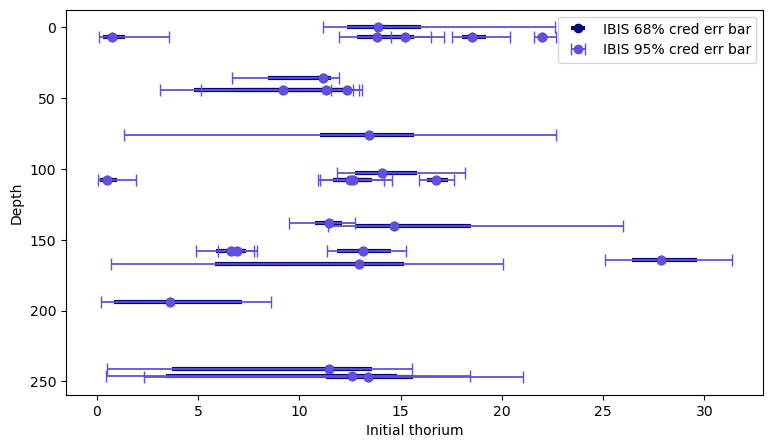

In [85]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,1, figsize = (9, 5))

ax.errorbar(y = df_summary['Depth_Meas'], 
            x = df_summary['initial thorium'],
            xerr = np.vstack([df_summary['Th0_err_lo68'], 
                             df_summary['Th0_err_hi68']]),
              fmt = 'o', lw = 3, 
            color = 'navy',
              label = 'IBIS 68% cred err bar')

ax.errorbar(y = df_summary['Depth_Meas'], 
            x = df_summary['initial thorium'],
            xerr = np.vstack([df_summary['Th0_err_lo95'], 
                             df_summary['Th0_err_hi95']]),
              fmt = 'o', lw = 1.3, 
              label = 'IBIS 95% cred err bar', 
           capsize = 4, 
           color = '#6050DC')


ax.legend()
ax.invert_yaxis()
ax.set_ylabel('Depth')
ax.set_xlabel('Initial thorium')

In [108]:
Moseley_Iso_Ages = np.array([5.4, 6.0, 7.3, 8.7]) * 1e3
Moseley_Iso_Errs = np.array([0.4, 0.8, 0.3, 0.5]) * 1e3

In [109]:
Depths = np.array([7, 44, 108, 158])

In [110]:
df_test = df_summary[np.isclose(df_summary['Depth_Meas'], Depths[0])]

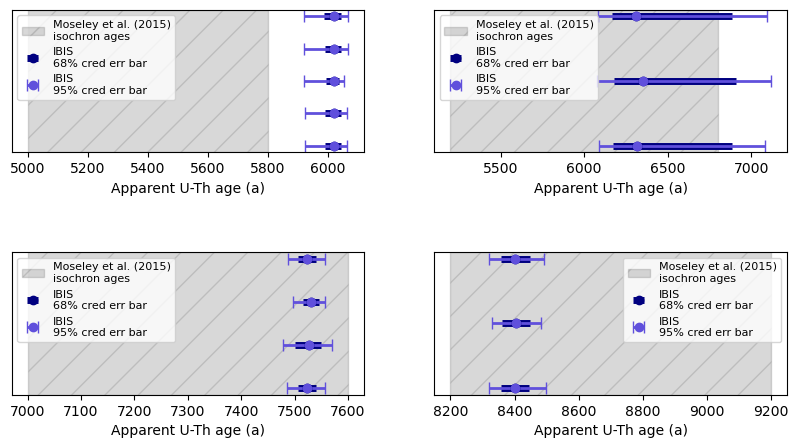

In [120]:
fig, ax = plt.subplots(2, 2, figsize = (10, 5), 
                      gridspec_kw={"hspace": 0.7})
axes = ax.flatten()

for i, ax_ in enumerate(axes): 
    df_test = df_summary[np.isclose(df_summary['Depth_Meas'], Depths[i])] 

    ax_.errorbar(y = np.arange(df_test.shape[0]), 
            x = df_test['age'],
            xerr = np.vstack([df_test['age_err_lo68'], 
                             df_test['age_err_hi68']]),
              fmt = 'o', lw = 5, 
            color = 'navy',
              label = 'IBIS\n68% cred err bar')

    ax_.errorbar(y = np.arange(df_test.shape[0]), 
            x = df_test['age'],
            xerr = np.vstack([df_test['age_err_lo95'], 
                             df_test['age_err_hi95']]),
              fmt = 'o', lw = 2,
              label = 'IBIS\n95% cred err bar', 
           capsize = 4, 
           color = '#6050DC')

    ax_.axvspan(Moseley_Iso_Ages[i] - Moseley_Iso_Errs[i], 
               Moseley_Iso_Ages[i] + Moseley_Iso_Errs[i], 
               label = 'Moseley et al. (2015)\nisochron ages', 
               color = 'grey', alpha = 0.3, hatch = '/')

    ax_.set_yticks([])
    ax_.set_xlabel('Apparent U-Th age (a)')
    ax_.legend(fontsize = 8, loc = 'upper left' if i in (0, 1, 2) else 'upper right')

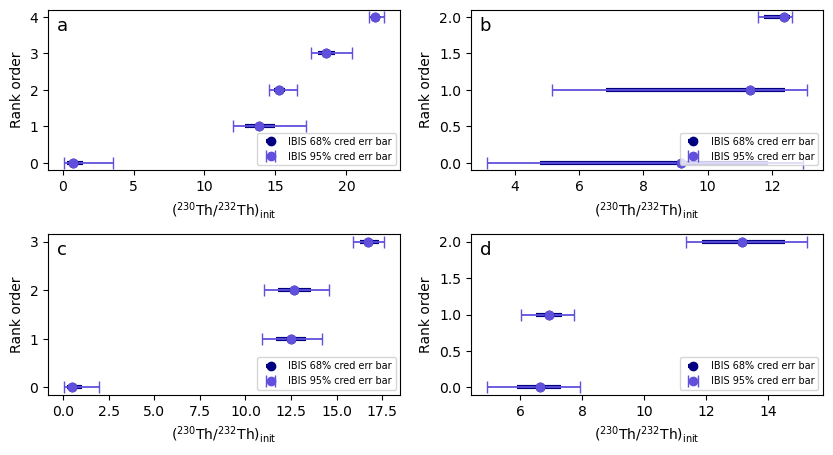

In [132]:
fig, ax = plt.subplots(2, 2, figsize = (10, 5), 
                      gridspec_kw={"hspace": 0.4})
axes = ax.flatten()
letters = 'abcd'
for i, ax_ in enumerate(axes): 
    df_test = df_summary[np.isclose(df_summary['Depth_Meas'], Depths[i])] 
    df_test = df_test.sort_values('initial thorium', ascending = True)
    ax_.errorbar(y = np.arange(df_test.shape[0]), 
                x = df_test['initial thorium'],
                xerr = np.vstack([df_test['Th0_err_lo68'], 
                                 df_test['Th0_err_hi68']]),
                  fmt = 'o', lw = 3, 
                color = 'navy',
                  label = 'IBIS 68% cred err bar')
    
    ax_.errorbar(y = np.arange(df_test.shape[0]), 
                x = df_test['initial thorium'],
                xerr = np.vstack([df_test['Th0_err_lo95'], 
                                 df_test['Th0_err_hi95']]),
                  fmt = 'o', lw = 1.3, 
                  label = 'IBIS 95% cred err bar', 
               capsize = 4, 
               color = '#6050DC')
    ax_.set_ylabel('Rank order')
    ax_.set_xlabel(r'($^{230}$Th/$^{232}$Th)$_{\rm init}$')
    ax_.text(0.025, 0.87, s = letters[i], 
    transform = ax_.transAxes, fontsize= 13)
    ax_.legend(loc = 'lower right', fontsize = 7)

# Notes
Figure above shows the IBIS derived initial thorium for the isochron samples. Clearly we see that there is heterogeneity in the initial estimates from IBIS despite being made across the same sample horizon. 
<br>
* This maybe shows spatially heterogeneity in initial thorium composition during the time of deposition.
* If the initial end member is heterogeneous, the assumption of the isochron are invalid. 